# Análisis de clientes y campañas de marketing

## Objetivo del proyecto

Analizar el comportamiento de los clientes para identificar qué perfiles presentan mayor potencial para futuras campañas de marketing.

> **Nota:** Este notebook conserva las anotaciones realizadas durante el aprendizaje. Las secciones se han organizado para que el análisis sea más fácil de seguir y presentar como proyecto de portfolio.


In [3]:
# Análisis de clientes y campañas de marketing
## Objetivo del proyecto

#Analizar el comportamiento de los clientes para identificar qué perfiles
#presentan mayor potencial para futuras campañas de marketing.


# 1. Carga y exploración de los datos

import pandas as pd
from google.colab import files
uploades=files.upload()

Saving marketing_campaign.csv to marketing_campaign (1).csv


## 1. Carga y exploración de los datos

En esta sección cargamos el dataset y hacemos una primera exploración de su estructura y variables.


In [4]:
with open("marketing_campaign.csv", "r", encoding="utf-8") as f:
    print(f.readline())

ID	Year_Birth	Education	Marital_Status	Income	Kidhome	Teenhome	Dt_Customer	Recency	MntWines	MntFruits	MntMeatProducts	MntFishProducts	MntSweetProducts	MntGoldProds	NumDealsPurchases	NumWebPurchases	NumCatalogPurchases	NumStorePurchases	NumWebVisitsMonth	AcceptedCmp3	AcceptedCmp4	AcceptedCmp5	AcceptedCmp1	AcceptedCmp2	Complain	Z_CostContact	Z_Revenue	Response



In [5]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")

In [6]:
df.shape

(2240, 29)

In [7]:
df.head(29)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,...,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,...,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,...,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,...,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,...,20,1,0,0,0,0,0,3,11,0


In [8]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

## 2. Creación de nuevas variables

Creamos `TotalSpend`, que representa el gasto total del cliente en las seis categorías de productos.


In [9]:
df ["TotalSpend"] = df ['MntWines']+df['MntFruits']+df['MntMeatProducts']+df['MntFishProducts']+df['MntSweetProducts']+df['MntGoldProds']

In [10]:
# 2. Creación de nuevas variables

#veo columna nueva creada

df[["ID", "TotalSpend"]].head()


,ID,TotalSpend
0,5524,1617
1,2174,27
2,4141,776
3,6182,53
4,5324,422


In [11]:
df.describe()


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,TotalSpend
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,605.798214
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,602.249288
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,5.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,68.750000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,396.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,1045.500000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,2525.000000


In [12]:
df["TotalSpend"].describe()

,TotalSpend
count,2240.000000
mean,605.798214
std,602.249288
min,5.000000
25%,68.750000
50%,396.000000
75%,1045.500000
max,2525.000000


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

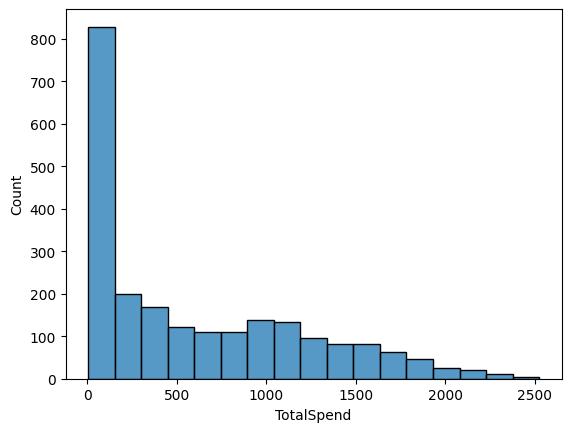

In [14]:
sns.histplot(data=df, x="TotalSpend")
plt.show()

In [15]:
type (df)


pandas.core.frame.DataFrame

In [16]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'TotalSpend'],
      dtype='object')

## 3. Segmentación de clientes

Definimos el segmento **High Value** utilizando como umbral un gasto total superior a 1.045,50 €.


In [17]:
#Definimos que en HighValueCustomer quiero tener los clientes
# que gastaron mas de 1045.50

df["HighValueCustomer"] = df["TotalSpend"] > 1045.50

In [18]:
# y quiero saber cuantos son, que me los cuente
df["HighValueCustomer"].value_counts()

,count
HighValueCustomer,
False,1680
True,560


Conclusion hasta ahora: El 25% de los clientes presenta un gasto superior a 1.045,50 €, por lo que puede considerarse un segmento de clientes de alto valor y merece ser analizado de forma diferenciada para diseñar estrategias de fidelización y campañas específicas.

In [19]:
#que solo me muestre la cantidad de clientes que gastaron mucho:
df[df["HighValueCustomer"] == True]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,TotalSpend,HighValueCustomer
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,0,3,11,1,1617,True
12,2125,1959,Graduation,Divorced,63033.0,0,0,15-11-2013,82,194,...,0,0,0,0,0,3,11,0,1102,True
15,2114,1946,PhD,Single,82800.0,0,0,24-11-2012,23,1006,...,0,1,1,0,0,3,11,1,1315,True
18,6565,1949,Master,Married,76995.0,0,1,28-03-2013,91,1012,...,0,0,1,0,0,3,11,0,1782,True
21,5376,1979,Graduation,Married,2447.0,1,0,06-01-2013,42,1,...,0,0,0,0,0,3,11,0,1730,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2221,7366,1982,Master,Single,75777.0,0,0,04-07-2013,12,712,...,1,1,0,0,0,3,11,1,1438,True
2228,8720,1978,2n Cycle,Together,NaN,0,0,12-08-2012,53,32,...,1,0,0,0,0,3,11,0,1679,True
2231,9817,1970,Master,Single,44802.0,0,0,21-08-2012,71,853,...,0,0,0,0,0,3,11,0,1049,True
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,0,0,0,0,0,3,11,0,1341,True


In [20]:
# de los clientes de compras caras, dime los descuentos:
df[df["HighValueCustomer"] == True]["NumDealsPurchases"]

,NumDealsPurchases
0,3
12,1
15,1
18,2
21,15
...,...
2221,1
2228,0
2231,2
2235,2


In [21]:
#de esta lista de compras con dto, dame el promedio:
df[df["HighValueCustomer"] == True]["NumDealsPurchases"].mean()

np.float64(1.8571428571428572)

In [22]:
#ahora calculamos de los clientes que no hicieron compras grandes,
# los descuentos que usaron:
df[df["HighValueCustomer"] == False]["NumDealsPurchases"].mean()

np.float64(2.480952380952381)

## 4. Análisis del comportamiento de compra

Comparamos el comportamiento de los clientes High Value y Low Value en descuentos y canales de compra.


In [23]:
# nueva variable que sume todas las compras por diferentes canales:
df["TotalPurchases"] = df["NumWebPurchases"] + df["NumCatalogPurchases"] + df["NumStorePurchases"]

In [24]:
df[["ID", "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "TotalPurchases"]].head()


,ID,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,TotalPurchases
0,5524,8,10,4,22
1,2174,1,1,2,4
2,4141,8,2,10,20
3,6182,2,0,4,6
4,5324,5,3,6,14


In [25]:
#promedio de compras de clientes de alto valor

df[df["HighValueCustomer"] == True]["TotalPurchases"].mean()

np.float64(19.992857142857144)

In [26]:
#proemdio de compras de clientes de bajo valor

df[df["HighValueCustomer"] == False]["TotalPurchases"].mean()

np.float64(10.051785714285714)

In [27]:
#Nueva variable para los clientes con alto gasto que vamos analizar:
high_value = df[df["HighValueCustomer"] == True]

#verificamos
high_value.shape

(560, 32)

## 5. Análisis del gasto por categoría

Analizamos cuánto gasta de media cada segmento en las diferentes categorías de productos.


In [28]:
#ponemos en la nueva variable, las columnas que queremos:
high_value[[
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]]

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,635,88,546,172,88,88
12,194,61,480,225,112,30
15,1006,22,115,59,68,45
18,1012,80,498,0,16,176
21,1,1,1725,1,1,1
...,...,...,...,...,...,...
2221,712,26,538,69,13,80
2228,32,2,1607,12,4,22
2231,853,10,143,13,10,20
2235,709,43,182,42,118,247


In [29]:
#media cada columna:
high_value[[
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]].mean()

,0
MntWines,739.273214
MntFruits,62.110714
MntMeatProducts,456.794643
MntFishProducts,89.471429
MntSweetProducts,63.892857
MntGoldProds,78.932143


In [30]:
#también analizamos si los de compras de menor
#valor gastan en vinos ó en que categoría
low_value = df[df["HighValueCustomer"] == False]


In [31]:
low_value.shape

(1680, 32)

In [32]:
#promedio de los gastos de menor importe (para esos 1680)
low_value[[
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]].mean()

,0
MntWines,158.823214
MntFruits,14.366071
MntMeatProducts,70.335119
MntFishProducts,20.210119
MntSweetProducts,14.786310
MntGoldProds,32.385119


In [33]:
739/159


4.647798742138365

In [34]:
import numpy as np

In [35]:
# si esto se cumple, pon esto, si no pon lo otro. Es el if else de numpy para
#columnas enteras de golpe (np.where)
df["CustomerGroup"] = np.where(
    df["HighValueCustomer"] == True,
    "High Value",
    "Low Value"
)
#para ver el resultado
df["CustomerGroup"].value_counts()

,count
CustomerGroup,
Low Value,1680
High Value,560


In [36]:
#calculamos promedio de la nueva variable separando high y low
# ojo! señalamos las columnas que queremos para que no sean tantas
# ademas que nos daría error pq tienen formatos letras algunas
df.groupby("CustomerGroup")[[
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]].mean()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
CustomerGroup,,,,,,
High Value,739.273214,62.110714,456.794643,89.471429,63.892857,78.932143
Low Value,158.823214,14.366071,70.335119,20.210119,14.786310,32.385119


In [37]:
#para graficar lo haremos en barplot (Seaborn)
# 1) creamos variable nueva agrupando la variable que habíamos creado
# y calculando media:

category_spend = df.groupby("CustomerGroup")[[
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]].mean().reset_index()

In [38]:
#compruebo nueva variable
category_spend

,CustomerGroup,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,High Value,739.273214,62.110714,456.794643,89.471429,63.892857,78.932143
1,Low Value,158.823214,14.366071,70.335119,20.210119,14.786310,32.385119


In [39]:
# convertir indice en columna:
# lo quito pq al final lo he sumado arriba con el otro codigo
# category_spend = category_spend.reset_index()


#creo nueva variable (category_spend_long donde voy alojar el nuevo grafico
# largo (indico las 3 columnas que quiero)
# le pongo melt para darle ese formato largo
#paso las columnas a filas

category_spend_long = category_spend.melt(
    id_vars="CustomerGroup",
    var_name="Category",
    value_name="AverageSpend"
)
#compruebo mi nueva variable
category_spend_long

,CustomerGroup,Category,AverageSpend
0,High Value,MntWines,739.273214
1,Low Value,MntWines,158.823214
2,High Value,MntFruits,62.110714
3,Low Value,MntFruits,14.366071
4,High Value,MntMeatProducts,456.794643
5,Low Value,MntMeatProducts,70.335119
6,High Value,MntFishProducts,89.471429
7,Low Value,MntFishProducts,20.210119
8,High Value,MntSweetProducts,63.892857
9,Low Value,MntSweetProducts,14.786310


## 6. Visualización del gasto por categoría

Transformamos los datos a formato largo y utilizamos un gráfico de barras para comparar ambos segmentos.


<Axes: xlabel='Category', ylabel='AverageSpend'>

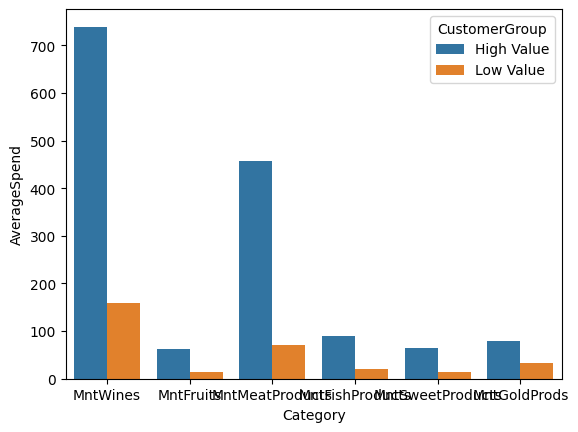

In [40]:
#grafico de barras
# hue es para diferenciar colores entre ambas variables

sns.barplot(
    data=category_spend_long,
    x="Category",
    y="AverageSpend",
    hue="CustomerGroup"
)

## 7. Perfil de los clientes y respuesta a campañas

Analizamos ingresos, composición del hogar y respuesta a las campañas de marketing.


In [41]:
df.columns
#trabajaremos con los dtos: NumDealsPurchases

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'TotalSpend', 'HighValueCustomer', 'TotalPurchases', 'CustomerGroup'],
      dtype='object')

In [43]:
#promedio de compras con dto:

df.groupby("CustomerGroup")["NumDealsPurchases"].mean()

,NumDealsPurchases
CustomerGroup,
High Value,1.857143
Low Value,2.480952


In [44]:
# calcule media de los tres métodos de compra que tengo:
df.groupby("CustomerGroup")[[
    "NumWebPurchases",
    "NumStorePurchases",
    "NumCatalogPurchases"
]].mean()

,NumWebPurchases,NumStorePurchases,NumCatalogPurchases
CustomerGroup,,,
High Value,5.605357,8.478571,5.908929
Low Value,3.577976,4.894048,1.579762


In [45]:
#comparamos los ingresos (promedio) de ambos grupos:
df.groupby("CustomerGroup")["Income"].mean()

,Income
CustomerGroup,
High Value,75238.190647
Low Value,44546.671687


In [46]:
# evaluaremos los grupos que tienen hijos (menores y adolescentes)

df.groupby("CustomerGroup")[["Kidhome", "Teenhome"]].mean()

,Kidhome,Teenhome
CustomerGroup,,
High Value,0.062500,0.316071
Low Value,0.571429,0.569643


In [47]:
#media de que grupo aceptó más campañas:
df.groupby("CustomerGroup")[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"]].mean()

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5
CustomerGroup,,,,,
High Value,0.200000,0.042857,0.092857,0.164286,0.267857
Low Value,0.019048,0.003571,0.066071,0.044643,0.007738


## 8. Conclusiones y recomendaciones de negocio


Conclusion final:
Ya puedes explicar nuestro cliente High Value así:

Representa el 25% de los clientes.
💰 Tiene un gasto medio mucho mayor que Low Value.
🍷 Sus categorías de mayor gasto son vino y carne.
🏷️ Realiza menos compras con descuento.
🛒 Compra más por web, tienda y catálogo.
💵 Tiene ingresos medios bastante superiores.
👨‍👩‍👧 Tiene, de media, menos niños y adolescentes en casa.
📢 Tiene una mayor aceptación de las campañas de marketing.
⭐ La campaña 5 destaca entre las campañas analizadas, con alrededor de un 27% de aceptación en High Value.

### Resumen profesional

El análisis muestra que los clientes **High Value**, que representan el 25% de la base de clientes, presentan un mayor gasto y mayores ingresos medios que los clientes Low Value. También realizan más compras a través de los distintos canales y presentan una mayor tasa de aceptación de las campañas analizadas.

El segmento High Value utiliza menos compras con descuento y destaca especialmente por su gasto en las categorías de **vino y carne**. La campaña 5 presenta la mayor aceptación dentro de este segmento, por lo que sería interesante analizar qué características de esa campaña pueden explicar su mejor respuesta.

### Recomendaciones

- Diseñar acciones específicas para clientes High Value en lugar de aplicar la misma estrategia a toda la base.
- Priorizar productos y categorías de mayor interés, especialmente vino y carne.
- Analizar en profundidad la campaña 5 para identificar elementos que puedan reutilizarse en futuras campañas.
- Estudiar estrategias de fidelización y beneficios exclusivos, ya que el segmento High Value muestra un alto nivel de gasto sin depender tanto de los descuentos.
